In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import glob
import tp2_reconstruccion_3d.code_examples.charuco_example.aruco as aruco
import auxiliares
import importlib
import utils_budha_checkerboard as ubc

# Calibracion

In [ ]:
# Parámetros del tablero checkerboard
checkerboard = (10, 7)          # número de esquinas internas
square_size_mm = 24.2           # tamaño del cuadrado en milímetros
square_size = square_size_mm / 1000.0  # convertir a metros

# Directiorio base de las imágenes de calibración
base_dir = "tp2_reconstruccion_3d/datasets/stereo_budha_charuco/calib"

# Cargar o calibrar camara estereo
calib_path = os.path.join(base_dir, "stereo_calib.pkl")
if not os.path.exists(calib_path):
    calib = ubc.calibrar_stereo_checkerboard(base_dir, ["left*.jpg", "right*.jpg"], checkerboard, square_size)
else:
    calib= ubc.cargar_calibracion_stereo(calib_path)

Pares válidos: 20
RMS left: 1.0192 | RMS right: 1.0374 | RMS stereo: 1.2477
Guardado: stereo_calibration.pkl


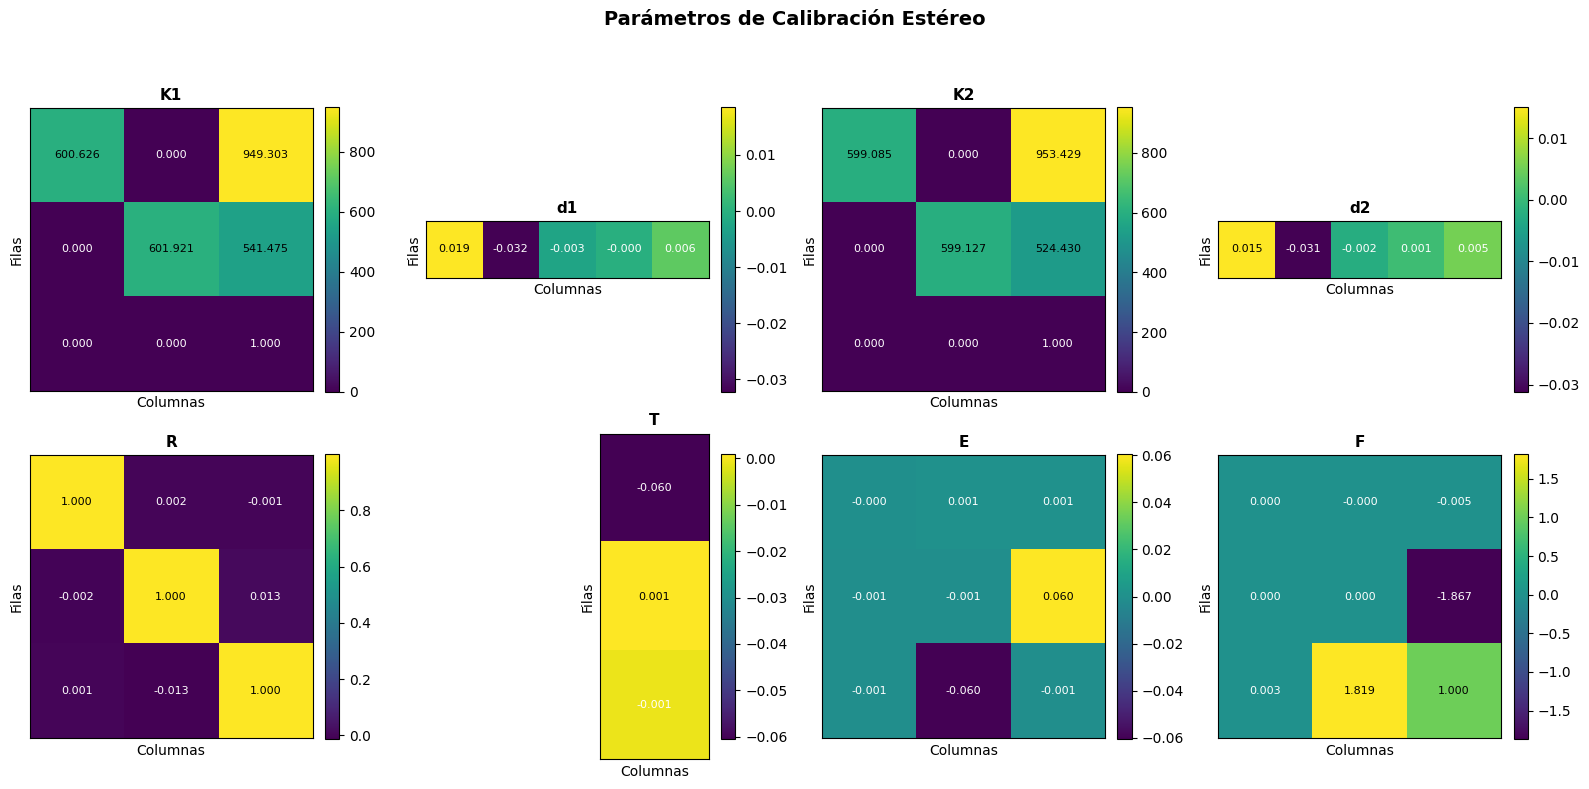

In [6]:
# Visualizar todas las matrices en una cuadrícula 2x4
ubc.graficar_matrices_calibracion(calib)

# Asignar variables principales (sin redefinir ni duplicar)
left_K, left_dist = calib["left_K"], calib["left_dist"]
right_K, right_dist = calib["right_K"], calib["right_dist"]
R, T = calib["R"], calib["T"]

# Rectificacion

✅ Mapas de rectificación guardados en: tp2_reconstruccion_3d/datasets/stereo_budha_charuco/calib/stereo_maps.pkl


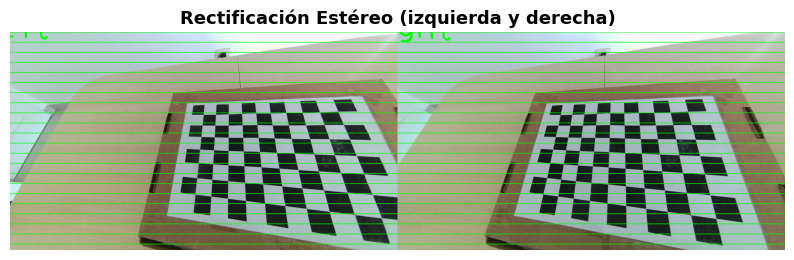

In [8]:
# Tamaño de imagen
image_size = ubc.inferir_image_size(calib, base_dir)

# Calcular la rectificación estéreo
R1, R2, P1, P2, Q, validRoi1, validRoi2 = ubc.calcular_rectificacion(calib, image_size, alpha=0)


# Generar los mapas de rectificación   
left_map_x, left_map_y, right_map_x, right_map_y = ubc.generar_mapas_rectificacion(
    calib, R1, R2, P1, P2, image_size
)

# Guardar los mapas
maps_file = os.path.join(base_dir, "stereo_maps.pkl")

stereo_maps = {
    "left_map_x": left_map_x,
    "left_map_y": left_map_y,
    "right_map_x": right_map_x,
    "right_map_y": right_map_y,
    "R1": R1,
    "R2": R2,
    "P1": P1,
    "P2": P2,
    "Q": Q,
    "validRoi1": validRoi1,
    "validRoi2": validRoi2,
    "image_size": image_size
}

ubc.guardar_stereo_maps(maps_file, stereo_maps)
print("✅ Mapas de rectificación guardados en:", maps_file)

# Visualizar la rectificación estéreo
left_img = sorted(glob.glob(os.path.join(base_dir, "*left*.jpg")))[0]
right_img = sorted(glob.glob(os.path.join(base_dir, "*right*.jpg")))[0]

ubc.visualizar_rectificacion(
    left_img, right_img, left_map_x, left_map_y, right_map_x, right_map_y,
    step=50, title="Rectificación Estéreo (izquierda y derecha)"
)

In [9]:
# Rectificar capturas y guardar ROI común (color)

# Cargar los mapas de rectificación generados en la calibración
maps_path = os.path.join(base_dir, "stereo_maps.pkl")
maps = ubc.cargar_stereo_maps(maps_path)

# Definir carpetas de entrada (capturas crudas) y salida (rectificadas)
captures_dir = "tp2_reconstruccion_3d/datasets/stereo_budha_charuco/captures"
out_roi = os.path.join(captures_dir, "rectificadas")

# Emparejar imágenes izquierda/derecha por nombre o índice
pares = ubc.emparejar_pares(captures_dir)

# Calcular la región común entre ambas cámaras (ROI válida compartida)
roi_comun = ubc.interseccion_rois(maps["validRoi1"], maps["validRoi2"])

# Aplicar la rectificación y guardar cada par recortado en la ROI común
procesados = ubc.rectificar_y_guardar_pares(
    pares,
    maps["left_map_x"], maps["left_map_y"],
    maps["right_map_x"], maps["right_map_y"],
    roi_comun, out_roi,
    indice_inicial=1, interpolacion=cv2.INTER_LINEAR
)

# Confirmar resultados
print("Rectificación de capturas completada.")
print("Directorio de salida:", out_roi)
print("Pares procesados:", procesados)


Rectificación de capturas completada.
Directorio de salida: tp2_reconstruccion_3d/datasets/stereo_budha_charuco/captures/rectificadas
Pares procesados: 21


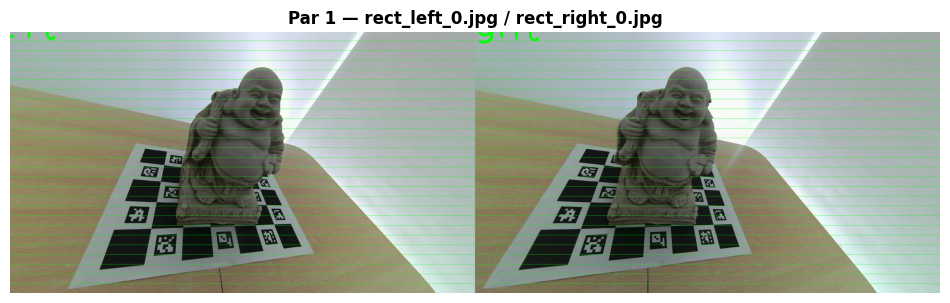

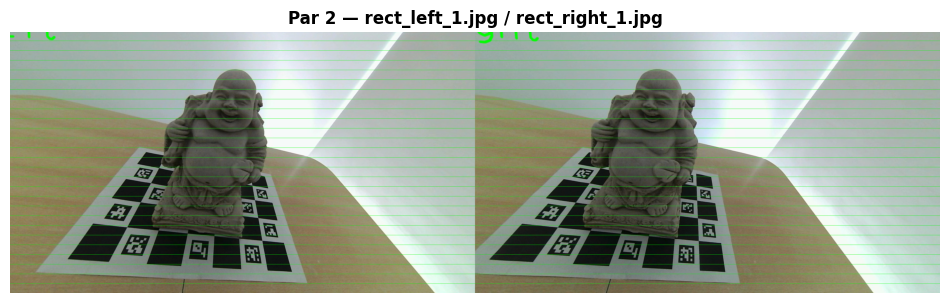

In [12]:
# Visualizar algunas imágenes rectificadas con líneas epipolares
ubc.visualizar_imagenes_rectificadas(
    path_rectificadas="tp2_reconstruccion_3d/datasets/stereo_budha_charuco/captures/rectificadas",
    step=40, n_mostrar=2
)

# Calculo de los mapas de disparidad

Se noto en los ejemplos de la muñeca y el del budha con el checkerboard que el mejor mapa de disparidad obtenido fue mediante CREStereo de la libreria de Stereodemo. Es por eso que solo se usa ese metodo para hacer el calculo del mapa de disparidad. 

In [ ]:
# Paths de entrada y salida
path_imgs = "tp2_reconstruccion_3d/datasets/stereo_budha_charuco/captures/rectificadas"
out_dir   = "tp2_reconstruccion_3d/datasets/stereo_budha_charuco/captures"

# Calcular disparidad con stereodemo
ubc.calcular_disparidad_stereodemo(path_imgs, out_dir, metodo="cre")

Imágenes encontradas: 21 pares
Método seleccionado: CRE


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:121: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Resultados guardados en: tp2_reconstruccion_3d/datasets/stereo_budha_charuco/captures/disparidad_cre


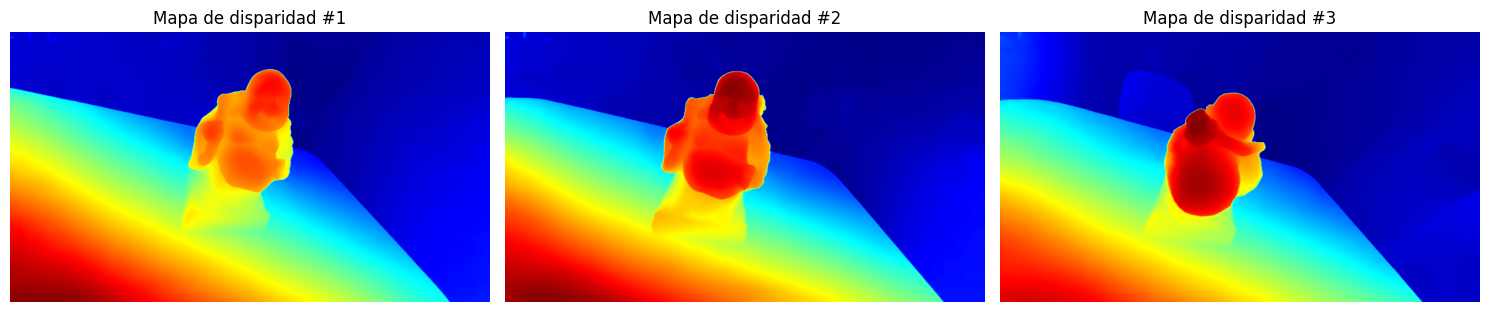

In [15]:
# Carpeta con los mapas de disparidad
path_disparidad = "tp2_reconstruccion_3d/datasets/stereo_budha_charuco/captures/disparidad_cre"

# Buscar mapas
disp_imgs = sorted(glob.glob(os.path.join(path_disparidad, "disp_color_*.png")))

# Mostrar algunos ejemplos
n = 3
fig, axes = plt.subplots(1, n, figsize=(15, 5))
for i in range(n):
    disp = cv2.imread(disp_imgs[i])
    disp_rgb = cv2.cvtColor(disp, cv2.COLOR_BGR2RGB)
    axes[i].imshow(disp_rgb)
    axes[i].set_title(f"Mapa de disparidad #{i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# Reconstruccion 3D

In [19]:
import open3d as o3d
importlib.reload(ubc)

# Configuración del Charuco Board
DICTIONARY_TYPE = cv2.aruco.DICT_6X6_250
SQUARES_X = 5
SQUARES_Y = 7
SQUARE_LENGTH = 52.6  # mm
MARKER_LENGTH = 31.3  # mm

# Crear diccionario y board de Charuco
aruco_dict = cv2.aruco.getPredefinedDictionary(DICTIONARY_TYPE)
charuco_board = cv2.aruco.CharucoBoard(
    (SQUARES_X, SQUARES_Y),
    SQUARE_LENGTH / 1000.0,  # convertir a metros
    MARKER_LENGTH / 1000.0,  # convertir a metros
    aruco_dict
)


# %%
# =========================================================
# 9. NUEVA FUNCIÓN: Dibujar marcadores Charuco
# =========================================================
def draw_charuco_markers(image, detection, draw_rejected=False):
    """
    Dibuja los resultados de la detección sobre la imagen.
    """
    output_image = image.copy()

    if detection is None:
        return output_image

    corners = detection["corners"]
    ids = detection["ids"]
    rejected = detection["rejected"]

    # Dibujar marcadores aceptados (verdes)
    if ids is not None and len(ids) > 0:
        output_image = cv2.aruco.drawDetectedMarkers(output_image, corners, ids)

    # Dibujar rechazados (rojos)
    if draw_rejected and rejected is not None and len(rejected) > 0:
        cv2.aruco.drawDetectedMarkers(
            output_image, rejected, borderColor=(0, 0, 255)
        )

    return output_image

# %%
# =========================================================
# 10. NUEVA FUNCIÓN: Visualizar detección de Charuco
# =========================================================
def visualizar_deteccion_charuco(image_path, camera_matrix, dist_coeffs, board):
    """
    Visualiza la detección de Charuco en una imagen con detalles completos.
    """
    img = cv2.imread(image_path)
    if img is None:
        print(f"❌ No se pudo cargar: {image_path}")
        return
    
    # Detectar marcadores
    detection = ubc.detect_charuco_markers(img, board)
    
    # Dibujar marcadores
    img_markers = draw_charuco_markers(img, detection, draw_rejected=True)
    
    if detection is None:
        print(f"❌ No se detectaron marcadores ArUco en {os.path.basename(image_path)}")
    else:
        print(f"✅ Detectados {len(detection['ids'])} marcadores ArUco")
        
        # Intentar estimar pose
        result = ubc.estimate_camera_pose_with_homography(
            img, board, detection, (camera_matrix, dist_coeffs), undistort=False
        )
        
        if result is not None:
            success, rvec, tvec = result
            if success:
                # Dibujar ejes de coordenadas
                axis_length = SQUARE_LENGTH / 1000.0 * 2  # 2 cuadrados de longitud
                cv2.drawFrameAxes(img_markers, camera_matrix, dist_coeffs, 
                                rvec, tvec, axis_length, thickness=3)
                print(f"✅ Pose estimada correctamente")
                print(f"   Traslación (x, y, z): ({tvec[0][0]:.3f}, {tvec[1][0]:.3f}, {tvec[2][0]:.3f}) m")
            else:
                print(f"❌ No se pudo estimar la pose")
        else:
            print(f"⚠️ Insuficientes marcadores para estimar pose")
    
    # Mostrar
    plt.figure(figsize=(15, 10))
    plt.imshow(cv2.cvtColor(img_markers, cv2.COLOR_BGR2RGB))
    title = f"Detección Charuco - {os.path.basename(image_path)}"
    if detection is not None and result is not None:
        title += " ✅"
    else:
        title += " ❌"
    plt.title(title, fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# %%
# =========================================================
# 11. NUEVA FUNCIÓN: Visualizar todas las detecciones
# =========================================================
def visualizar_todas_detecciones_charuco(base_dir, calib_path, max_images=5):
    """
    Visualiza la detección de Charuco en múltiples imágenes
    """
    with open(calib_path, "rb") as f:
        calib = pickle.load(f)
    
    left_K = calib["left_K"]
    left_dist = calib["left_dist"]
    
    left_imgs = sorted(glob.glob(os.path.join(base_dir, "left_*.jpg")))
    
    print(f"🔍 Visualizando detección de Charuco en {min(max_images, len(left_imgs))} imágenes...\n")
    
    for i, img_path in enumerate(left_imgs[:max_images]):
        print(f"\n{'='*60}")
        print(f"Imagen {i+1}: {os.path.basename(img_path)}")
        print(f"{'='*60}")
        visualizar_deteccion_charuco(img_path, left_K, left_dist, charuco_board)


# %%
# =========================================================
# 13.5 NUEVA FUNCIÓN: Convertir a escala de grises
# =========================================================
def convertir_a_escala_grises(point_cloud):
    """
    Convierte los colores RGB de una nube de puntos a escala de grises
    usando la fórmula estándar de luminancia.
    
    Args:
        point_cloud: o3d.geometry.PointCloud con colores
    
    Returns:
        point_cloud: misma nube con colores en escala de grises
    """
    if not point_cloud.has_colors():
        print("⚠️ La nube no tiene colores para convertir")
        # Pintar de gris uniforme si no tiene colores
        point_cloud.paint_uniform_color([0.5, 0.5, 0.5])
        return point_cloud
    
    colors = np.asarray(point_cloud.colors)
    
    # Fórmula estándar de luminancia: Y = 0.299R + 0.587G + 0.114B
    gray_values = 0.299 * colors[:, 0] + 0.587 * colors[:, 1] + 0.114 * colors[:, 2]
    
    # Crear colores en escala de grises (mismo valor en R, G, B)
    gray_colors = np.column_stack([gray_values, gray_values, gray_values])
    
    point_cloud.colors = o3d.utility.Vector3dVector(gray_colors)
    
    print(f"✅ Nube convertida a escala de grises: {len(gray_colors)} puntos")
    
    return point_cloud

# %%
# =========================================================
# 14. FUNCIÓN PRINCIPAL: Reconstrucción 3D mejorada (EN ESCALA DE GRISES)
# =========================================================
def reconstruccion_3d_completa_corregida(max_distance=0.8, voxel_size=0.002, max_images=None, min_markers=6, filtrar_planos=True):
    """
    Pipeline de reconstrucción 3D con sistema de referencia FIJO
    
    Args:
        max_distance: Distancia máxima en metros
        voxel_size: Tamaño de voxel para downsampling
        max_images: Número máximo de imágenes (None = todas)
        min_markers: Mínimo de marcadores ArUco requeridos
        filtrar_planos: Si True, elimina planos grandes (fondo/mesa)
    """
    base_dir = "tp2_reconstruccion_3d/datasets/stereo_budha_charuco"
    calib_path = os.path.join(base_dir, "calib/stereo_calibration.pkl")
    maps_path = os.path.join(base_dir, "calib/stereo_maps.pkl")
    
    with open(calib_path, "rb") as f:
        calib = pickle.load(f)
    with open(maps_path, "rb") as f:
        maps = pickle.load(f)
    
    left_K = calib["left_K"]
    left_dist = calib["left_dist"]
    Q = maps["Q"]
    
    captures_dir = os.path.join(base_dir, "captures")
    disparity_dir = os.path.join(captures_dir, "disparidad_cre")
    
    left_imgs_original = sorted(glob.glob(os.path.join(captures_dir, "left_*.jpg")))
    
    if max_images is not None:
        left_imgs_original = left_imgs_original[:max_images]
        print(f"⚠️  MODO DEBUG: Procesando solo {max_images} imágenes")
    
    all_point_clouds = []
    successful_reconstructions = 0
    
    print("🔹 Iniciando reconstrucción 3D con sistema de referencia FIJO...")
    print(f"   Parámetros: max_distance={max_distance}m, voxel_size={voxel_size}m")
    print(f"   Min marcadores: {min_markers}\n")
    
    for i, left_img_path in enumerate(left_imgs_original):
        print(f"\n{'='*60}")
        print(f"Procesando imagen {i+1}/{len(left_imgs_original)}: {os.path.basename(left_img_path)}")
        print(f"{'='*60}")
        
        left_img_original = cv2.imread(left_img_path)
        if left_img_original is None:
            print(f"❌ Error cargando imagen")
            continue
        
        success, rvec, tvec, corners, ids = ubc.detect_charuco_pose(
            left_img_original, left_K, left_dist, charuco_board, verbose=True
        )
        
        # Validaciones
        if not success or ids is None or len(ids) < min_markers:
            print(f"❌ Insuficientes marcadores: {len(ids) if ids is not None else 0}/{min_markers}")
            continue
        
        dist_to_camera = np.linalg.norm(tvec)
        if dist_to_camera > max_distance * 1.5 or dist_to_camera < 0.1:
            print(f"❌ Distancia no física: {dist_to_camera:.3f}m")
            continue
        
        R_world, _ = cv2.Rodrigues(rvec)
        det_R = np.linalg.det(R_world)
        if abs(det_R - 1.0) > 0.1:
            print(f"❌ Rotación inválida: det(R)={det_R:.4f}")
            continue
        
        print(f"✅ Charuco OK: {len(ids)} marcadores, dist={dist_to_camera:.3f}m")
        
        # =========================================================
        # 🔑 TRANSFORMACIÓN CORRECTA: TODO en sistema del board
        # =========================================================
        
        # ENTENDER EL PROBLEMA:
        # - rvec, tvec te dan: T_camera_board (board visto desde cámara)
        # - Los puntos 3D están en sistema de cámara OpenCV
        # - Queremos: puntos en sistema del board (mundo)
        
        # PASO 1: Crear transformación board→camera
        R_board_to_cam, _ = cv2.Rodrigues(rvec)
        T_board_to_cam = ubc.create_transform_matrix(rvec, tvec)
        
        # PASO 2: Invertir para obtener camera→board
        T_cam_to_board = np.linalg.inv(T_board_to_cam)
        
        # 🎯 CLAVE: NO aplicar corrección OpenCV→Open3D
        # Los puntos de cv2.reprojectImageTo3D YA están en el sistema correcto
        # Solo necesitamos transformarlos al sistema del board
        
        W_T_C = T_cam_to_board
        
        print(f"   🔍 Transformación cámara→mundo:")
        print(f"      Traslación: {T_cam_to_board[:3, 3]}")
        print(f"      det(R): {np.linalg.det(T_cam_to_board[:3, :3]):.4f}")
        
        # =========================================================
        # PROCESAR DISPARIDAD Y CREAR NUBE
        # =========================================================
        
        base_name = os.path.basename(left_img_path).replace("left_", "").replace(".jpg", "")
        disp_path = os.path.join(disparity_dir, f"disp_raw_{base_name}.npy")
        
        if not os.path.exists(disp_path):
            print(f"❌ No existe disparidad")
            continue
        
        disparity = np.load(disp_path)
        
        valid_disp_ratio = np.sum(disparity > 0) / disparity.size
        if valid_disp_ratio < 0.1:
            print(f"❌ Disparidad pobre: {valid_disp_ratio*100:.1f}%")
            continue
        
        print(f"   📊 Disparidad válida: {valid_disp_ratio*100:.1f}%")
        
        points_3d = cv2.reprojectImageTo3D(disparity, Q)
        
        # Filtrado estricto
        mask = np.ones(disparity.shape, dtype=bool)
        mask &= (disparity > 0)
        mask &= np.isfinite(points_3d[:, :, 0])
        mask &= np.isfinite(points_3d[:, :, 1])
        mask &= np.isfinite(points_3d[:, :, 2])
        
        distances = np.linalg.norm(points_3d, axis=2)
        mask &= (distances < max_distance) & (distances > 0.05)
        mask &= (points_3d[:, :, 2] > 0.05) & (points_3d[:, :, 2] < max_distance)
        
        # 🔹 FILTRO MEJORADO: Limitar X e Y más estrictamente
        x_valid = (points_3d[:, :, 0] > -0.3) & (points_3d[:, :, 0] < 0.3)
        y_valid = (points_3d[:, :, 1] > -0.3) & (points_3d[:, :, 1] < 0.3)
        mask &= x_valid & y_valid
        
        # 🔹 NUEVO: Filtrar por gradiente de profundidad (elimina planos grandes)
        if filtrar_planos:
            # Calcular gradiente de la disparidad
            grad_x = cv2.Sobel(disparity, cv2.CV_64F, 1, 0, ksize=3)
            grad_y = cv2.Sobel(disparity, cv2.CV_64F, 0, 1, ksize=3)
            grad_mag = np.sqrt(grad_x**2 + grad_y**2)
            
            # Mantener solo puntos con gradiente alto (bordes, detalles)
            # O puntos en regiones con alta variación local
            mask &= (grad_mag > 1.0) | (disparity > np.percentile(disparity[disparity > 0], 60))
        
        valid_points = points_3d[mask]
        
        if len(valid_points) < 100:
            print(f"❌ Muy pocos puntos: {len(valid_points)}")
            continue
        
        print(f"   📊 Puntos válidos: {len(valid_points)}")
        
        # Extraer colores
        img_left_color = cv2.imread(left_img_path)
        img_left_color = cv2.cvtColor(img_left_color, cv2.COLOR_BGR2RGB)
        
        if img_left_color.shape[:2] != disparity.shape:
            img_left_color = cv2.resize(img_left_color, 
                                        (disparity.shape[1], disparity.shape[0]))
        
        colors = img_left_color.reshape(-1, 3) / 255.0
        valid_colors = colors[mask.flatten()]
        
        # Crear nube en sistema de cámara
        point_cloud = o3d.geometry.PointCloud()
        point_cloud.points = o3d.utility.Vector3dVector(valid_points)
        point_cloud.colors = o3d.utility.Vector3dVector(valid_colors)
        
        # ✨ TRANSFORMAR al sistema del board (SIN corrección OpenCV/Open3D)
        points_camera = np.array(point_cloud.points)
        points_camera_homogeneous = np.column_stack([points_camera, 
                                                     np.ones(len(points_camera))])
        
        # Aplicar transformación directa cámara → board
        points_world_homogeneous = (W_T_C @ points_camera_homogeneous.T).T
        points_world = points_world_homogeneous[:, :3] / points_world_homogeneous[:, 3:4]
        
        point_cloud.points = o3d.utility.Vector3dVector(points_world)
        
        # ✅ FILTRADO ESTADÍSTICO más agresivo
        cl, ind = point_cloud.remove_statistical_outlier(nb_neighbors=30, std_ratio=1.5)
        point_cloud = point_cloud.select_by_index(ind)
        
        print(f"   📉 Post-filtro estadístico: {len(point_cloud.points)} puntos")
        
        # 🔹 NUEVO: Filtrar por densidad (elimina puntos aislados)
        if len(point_cloud.points) > 100:
            cl, ind = point_cloud.remove_radius_outlier(nb_points=10, radius=0.02)
            point_cloud = point_cloud.select_by_index(ind)
            print(f"   📉 Post-filtro de densidad: {len(point_cloud.points)} puntos")
        
        # Downsample
        point_cloud = point_cloud.voxel_down_sample(voxel_size=voxel_size)
        
        all_point_clouds.append(point_cloud)
        successful_reconstructions += 1
        
        print(f"✅ Nube procesada: {len(point_cloud.points)} puntos")
        
        # 🔍 DEBUG: Mostrar posición de la nube en el mundo
        center = np.mean(np.asarray(point_cloud.points), axis=0)
        print(f"   🌍 Centro de nube en mundo: [{center[0]:.3f}, {center[1]:.3f}, {center[2]:.3f}]")
    
    # =========================================================
    # COMBINAR Y VISUALIZAR
    # =========================================================
    
    if len(all_point_clouds) == 0:
        print("\n❌ No se generaron puntos 3D")
        return None
    
    print(f"\n🔗 Combinando {len(all_point_clouds)} nubes...")
    
    all_points = []
    all_colors = []
    
    for pc in all_point_clouds:
        pts = np.asarray(pc.points)
        all_points.append(pts)
        
        if pc.has_colors() and len(pc.colors) == len(pc.points):
            all_colors.append(np.asarray(pc.colors))
        else:
            all_colors.append(np.full((pts.shape[0], 3), 0.7))
    
    combined_points = np.vstack(all_points)
    combined_colors = np.vstack(all_colors)
    
    point_cloud_combined = o3d.geometry.PointCloud()
    point_cloud_combined.points = o3d.utility.Vector3dVector(combined_points)
    point_cloud_combined.colors = o3d.utility.Vector3dVector(combined_colors)
    
    print(f"\n{'='*60}")
    print(f"🎉 RECONSTRUCCIÓN COMPLETADA")
    print(f"{'='*60}")
    print(f"   Imágenes exitosas: {successful_reconstructions}/{len(left_imgs_original)}")
    print(f"   Total puntos: {len(combined_points)}")
    
    pts = np.asarray(point_cloud_combined.points)
    print(f"\n📊 Distribución espacial:")
    print(f"   X: [{pts[:,0].min():.3f}, {pts[:,0].max():.3f}] m")
    print(f"   Y: [{pts[:,1].min():.3f}, {pts[:,1].max():.3f}] m")
    print(f"   Z: [{pts[:,2].min():.3f}, {pts[:,2].max():.3f}] m")
    print(f"{'='*60}\n")
    
    # # Escala de grises
    # point_cloud_gray = o3d.geometry.PointCloud(point_cloud_combined)
    # point_cloud_gray = convertir_a_escala_grises(point_cloud_gray)
    
    # 🔹 NUEVO: Filtrado final para eliminar planos residuales
    if filtrar_planos and len(point_cloud_combined.points) > 1000:
        print("\n🧹 Aplicando filtrado final de planos...")
        
        # Segmentar plano dominante (mesa/fondo)
        plane_model, inliers = point_cloud_combined.segment_plane(
            distance_threshold=0.01,
            ransac_n=3,
            num_iterations=1000
        )
        
        # Mantener solo los outliers (el objeto, no el plano)
        outlier_cloud = point_cloud_combined.select_by_index(inliers, invert=True)
        
        print(f"   📉 Plano removido: {len(inliers)} puntos")
        print(f"   ✅ Puntos del objeto: {len(outlier_cloud.points)} puntos")
        
        point_cloud_combined = outlier_cloud
    
    # Visualización con marcos de referencia
    coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(
        size=0.1, origin=[0, 0, 0]
    )
    
    print("🔍 Visualizando reconstrucción alineada...")
    o3d.visualization.draw_geometries(
        [point_cloud_combined, coordinate_frame],
        window_name=f"Reconstrucción ALINEADA - {successful_reconstructions} imágenes",
        width=1280,
        height=720
    )
    
    # Exportar
    output_path = os.path.join(base_dir, 
                              f"reconstruccion_alineada_{successful_reconstructions}imgs.ply")
    o3d.io.write_point_cloud(output_path, point_cloud_combined)
    print(f"💾 Guardado: {output_path}")

    return point_cloud_combined

# %%
# =========================================================
# 15. FUNCIÓN: Calcular centro robusto ignorando outliers
# =========================================================
def calcular_centro_robusto(points, percentile_range=(5, 95)):
    """
    Calcula el centro de la nube de puntos ignorando outliers
    usando percentiles en lugar de min/max
    
    Args:
        points: numpy array de puntos (N, 3)
        percentile_range: tupla (min_percentile, max_percentile)
    
    Returns:
        centro: numpy array (3,) con el centro robusto
    """
    min_p, max_p = percentile_range
    
    # Calcular límites usando percentiles para ignorar outliers
    x_min = np.percentile(points[:, 0], min_p)
    x_max = np.percentile(points[:, 0], max_p)
    y_min = np.percentile(points[:, 1], min_p)
    y_max = np.percentile(points[:, 1], max_p)
    z_min = np.percentile(points[:, 2], min_p)
    z_max = np.percentile(points[:, 2], max_p)
    
    centro = np.array([
        (x_min + x_max) / 2,
        (y_min + y_max) / 2,
        (z_min + z_max) / 2
    ])
    
    print(f"\n🎯 Centro calculado (robusto con percentiles {min_p}-{max_p}):")
    print(f"   X: {centro[0]:.4f} (rango: {x_min:.4f} a {x_max:.4f})")
    print(f"   Y: {centro[1]:.4f} (rango: {y_min:.4f} a {y_max:.4f})")
    print(f"   Z: {centro[2]:.4f} (rango: {z_min:.4f} a {z_max:.4f})")
    
    return centro


# %%
# =========================================================
# 16. FUNCIÓN: Bounding box basado en percentiles
# =========================================================
def crear_bounding_box_percentil(points, percentile=95, margin_factor=1.2):
    """
    Crea un bounding box basado en percentiles para ignorar outliers
    
    Args:
        points: numpy array de puntos (N, 3)
        percentile: percentil para definir los límites (95 ignora el 5% de outliers)
        margin_factor: factor de margen adicional (1.2 = 20% más grande)
    
    Returns:
        center, extent: centro y extensión del bounding box
    """
    # Calcular centro robusto
    center = calcular_centro_robusto(points, percentile_range=(100-percentile, percentile))
    
    # Calcular dimensiones usando percentiles
    min_p = 100 - percentile
    max_p = percentile
    
    width_x = np.percentile(points[:, 0], max_p) - np.percentile(points[:, 0], min_p)
    width_y = np.percentile(points[:, 1], max_p) - np.percentile(points[:, 1], min_p)
    width_z = np.percentile(points[:, 2], max_p) - np.percentile(points[:, 2], min_p)
    
    # Aplicar margen
    extent = [
        width_x * 0.4 / 2,
        width_y * 0.4 / 2,
        width_z * 0.6 / 2
    ]
    
    print(f"\n📦 Dimensiones del bounding box (con margen {margin_factor}x):")
    print(f"   Ancho  (X): {width_x:.4f} m → extent: {extent[0]:.4f} m")
    print(f"   Alto   (Y): {width_y:.4f} m → extent: {extent[1]:.4f} m")
    print(f"   Fondo  (Z): {width_z:.4f} m → extent: {extent[2]:.4f} m")
    
    return center, extent


# %%
# =========================================================
# 17. Filtrado por bounding box (MEJORADO)
# =========================================================
def crear_bounding_box_filtro(center, extent):
    """
    Crea un bounding box orientado para filtrar puntos con color rojo
    """
    bbox = o3d.geometry.OrientedBoundingBox(center, np.eye(3), extent)
    bbox.color = [1.0, 0.0, 0.0]  # ✨ Rojo brillante
    return bbox

def filtrar_por_bounding_box(point_cloud, center, extent):
    """
    Filtra puntos dentro de un bounding box preservando colores.
    """
    bbox = crear_bounding_box_filtro(center, extent)

    idx = bbox.get_point_indices_within_bounding_box(point_cloud.points)
    idx = np.asarray(idx, dtype=np.int64)

    filtered_pc = o3d.geometry.PointCloud()

    pts = np.asarray(point_cloud.points)
    if idx.size == 0:
        print("⚠️ El bbox no contiene puntos.")
        return filtered_pc, bbox

    filtered_pts = pts[idx]
    filtered_pc.points = o3d.utility.Vector3dVector(filtered_pts)

    # Copiar colores solo si existen y están alineados
    if point_cloud.has_colors():
        cols = np.asarray(point_cloud.colors)
        if cols.shape[0] == pts.shape[0]:
            filtered_cols = cols[idx]
            filtered_pc.colors = o3d.utility.Vector3dVector(filtered_cols)
        else:
            print("⚠️ Los colores no coinciden en longitud con los puntos. Pintando uniforme.")
            filtered_pc.paint_uniform_color([0.6, 0.6, 0.6])
    else:
        print("⚠️ La nube original no tenía colores. Pintando uniforme.")
        filtered_pc.paint_uniform_color([0.6, 0.6, 0.6])

    return filtered_pc, bbox


# %%
# =========================================================
# 18. Análisis de calidad de detecciones
# =========================================================
def analizar_calidad_detecciones():
    """
    Analiza todas las imágenes y reporta la calidad de detección
    """
    print("\n" + "=" * 80)
    print("ANÁLISIS DE CALIDAD DE DETECCIÓN")
    print("=" * 80)
    
    base_dir = "tp2_reconstruccion_3d/datasets/stereo_budha_charuco"
    calib_path = os.path.join(base_dir, "calib/stereo_calibration.pkl")
    
    with open(calib_path, "rb") as f:
        calib = pickle.load(f)
    
    left_K = calib["left_K"]
    left_dist = calib["left_dist"]
    
    captures_dir = os.path.join(base_dir, "captures")
    left_imgs = sorted(glob.glob(os.path.join(captures_dir, "left_*.jpg")))
    
    resultados = []
    
    for img_path in left_imgs:
        img = cv2.imread(img_path)
        if img is None:
            continue
        
        success, rvec, tvec, corners, ids = ubc.detect_charuco_pose(
            img, left_K, left_dist, charuco_board
            , verbose=False
        )
        
        # Contar marcadores detectados
        num_markers = len(ids) if ids is not None else 0
        
        resultados.append({
            'imagen': os.path.basename(img_path),
            'exito': success,
            'num_marcadores': num_markers,
            'tvec': tvec.flatten() if tvec is not None else None
        })
    
    # Imprimir tabla de resultados
    print(f"\n{'Imagen':<15} {'Estado':<10} {'Marcadores':<12} {'Posición (x, y, z)'}")
    print("-" * 80)
    
    exitos = 0
    for r in resultados:
        estado = "✅ OK" if r['exito'] else "❌ FALLO"
        if r['exito']:
            exitos += 1
            pos = f"({r['tvec'][0]:.3f}, {r['tvec'][1]:.3f}, {r['tvec'][2]:.3f})"
        else:
            pos = "N/A"
        
        print(f"{r['imagen']:<15} {estado:<10} {r['num_marcadores']:<12} {pos}")
    
    print("-" * 80)
    print(f"\n📊 RESUMEN:")
    print(f"   Total de imágenes: {len(resultados)}")
    print(f"   Detecciones exitosas: {exitos}")
    print(f"   Detecciones fallidas: {len(resultados) - exitos}")
    print(f"   Tasa de éxito: {100 * exitos / len(resultados):.1f}%")
    
    return resultados

# %%
# =========================================================
# ANÁLISIS DE CALIDAD COMPLETO
# =========================================================
resultados_deteccion = analizar_calidad_detecciones()

# %%
# =========================================================
# RECONSTRUCCIÓN 3D CON PARÁMETROS AJUSTABLES
# =========================================================
print("\n" + "=" * 80)
print("PASO 2: RECONSTRUCCIÓN 3D COMPLETA")
print("=" * 80)

# Ejecutar reconstrucción con filtrado mejorado
point_cloud_final = reconstruccion_3d_completa_corregida(
    max_distance=2.0,    # Máxima distancia en metros desde la cámara
    voxel_size=0.001     # Tamaño de voxel para downsampling (1mm)
)

# %%
# =========================================================
# FILTRADO POR BOUNDING BOX CON MÉTODO AUTOMÁTICO ✨ (ESCALA DE GRISES)
# =========================================================

if point_cloud_final is not None and len(point_cloud_final.points) > 0:
    print("\n" + "=" * 80)
    print("PASO 3: FILTRADO POR BOUNDING BOX (MÉTODO AUTOMÁTICO)")
    print("=" * 80)
    
    # Estadísticas de la nube de puntos
    print("\n📊 Estadísticas de la nube de puntos:")
    print(f"   Total de puntos: {len(point_cloud_final.points)}")
    
    points = np.asarray(point_cloud_final.points)
    print(f"   Rango X: [{points[:, 0].min():.3f}, {points[:, 0].max():.3f}]")
    print(f"   Rango Y: [{points[:, 1].min():.3f}, {points[:, 1].max():.3f}]")
    print(f"   Rango Z: [{points[:, 2].min():.3f}, {points[:, 2].max():.3f}]")
    
    # Calcular bounding box automático
    print("\n🎯 Calculando bounding box automático con percentiles...")
    center, extent = crear_bounding_box_percentil(
        points, 
        percentile=99,
    )
    
    offset = np.array([0.0, 0.0, 0.0])
    center_final = center + offset
    
    print(f"\n🔲 Aplicando bounding box automático:")
    print(f"   Centro: [{center_final[0]:.4f}, {center_final[1]:.4f}, {center_final[2]:.4f}]")
    print(f"   Extensión: [{extent[0]:.4f}, {extent[1]:.4f}, {extent[2]:.4f}]")
    
    # Filtrar puntos
    filtered_pc, bbox = filtrar_por_bounding_box(point_cloud_final, center_final, extent)
    
    print(f"\n📦 Puntos después de filtrado: {len(filtered_pc.points)}")
    print(f"   Porcentaje retenido: {100 * len(filtered_pc.points) / len(points):.1f}%")
    
    # Crear sistema de coordenadas
    coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(
        size=0.1, origin=[0, 0, 0]
    )

    # ✨ VISUALIZACIÓN SIMPLE EN ESCALA DE GRISES
    print("\n🔍 Visualizando nube filtrada en escala de grises...")
    
    o3d.visualization.draw_geometries(
        [filtered_pc, bbox, coordinate_frame],
        window_name="Nube filtrada (escala de grises con bbox rojo)",
        width=1280,
        height=720,
        point_show_normal=False
    )

    # Exportar versión filtrada en escala de grises
    output_filtered = "tp2_reconstruccion_3d/datasets/stereo_budha_charuco/reconstruccion_filtrada_grises.ply"
    o3d.io.write_point_cloud(output_filtered, filtered_pc, write_ascii=False)
    print(f"💾 Nube de puntos filtrada en escala de grises guardada en: {output_filtered}")


ANÁLISIS DE CALIDAD DE DETECCIÓN

Imagen          Estado     Marcadores   Posición (x, y, z)
--------------------------------------------------------------------------------
left_0.jpg      ✅ OK       7            (0.099, 0.023, 0.530)
left_1.jpg      ✅ OK       7            (0.100, 0.055, 0.497)
left_10.jpg     ✅ OK       9            (-0.250, 0.139, 0.205)
left_11.jpg     ✅ OK       7            (-0.368, 0.062, 0.295)
left_12.jpg     ✅ OK       8            (-0.396, 0.014, 0.430)
left_13.jpg     ✅ OK       7            (-0.359, -0.030, 0.448)
left_14.jpg     ✅ OK       7            (-0.392, -0.057, 0.528)
left_15.jpg     ✅ OK       6            (-0.316, -0.056, 0.639)
left_16.jpg     ✅ OK       7            (-0.249, -0.054, 0.677)
left_17.jpg     ✅ OK       7            (-0.176, -0.043, 0.650)
left_18.jpg     ✅ OK       8            (-0.101, 0.001, 0.596)
left_19.jpg     ✅ OK       7            (0.056, 0.053, 0.544)
left_2.jpg      ✅ OK       8            (0.100, 0.090, 0.492)
left_

In [20]:
# # =========================================================
# # 🚀 EJEMPLOS DE USO CON DIFERENTES CONFIGURACIONES
# # =========================================================

# # 🎯 CONFIGURACIÓN 1: Debug rápido (3 imágenes, con planos)
# print("="*80)
# print("PRUEBA 1: 3 imágenes (con planos de fondo)")
# print("="*80)
# pc_debug = reconstruccion_3d_completa_corregida(
#     max_distance=0.8,
#     voxel_size=0.002,
#     max_images=3,
#     min_markers=6,
#     filtrar_planos=False  # Ver todo incluyendo fondo
# )

# # 🎯 CONFIGURACIÓN 2: Solo objeto (3 imágenes, SIN planos)
# print("\n" + "="*80)
# print("PRUEBA 2: 3 imágenes (solo objeto, sin fondo)")
# print("="*80)
# pc_clean = reconstruccion_3d_completa_corregida(
#     max_distance=0.8,
#     voxel_size=0.002,
#     max_images=3,
#     min_markers=6,
#     filtrar_planos=True  # Eliminar planos grandes
# )

# # 🎯 CONFIGURACIÓN 3: Reconstrucción densa (5 imágenes)
# print("\n" + "="*80)
# print("PRUEBA 3: 5 imágenes (reconstrucción más densa)")
# print("="*80)
# pc_dense = reconstruccion_3d_completa_corregida(
#     max_distance=0.8,
#     voxel_size=0.001,  # Más denso
#     max_images=5,
#     min_markers=6,
#     filtrar_planos=True
# )

# 🎯 CONFIGURACIÓN 4: Todas las imágenes (resultado final)
print("\n" + "="*80)
print("PRUEBA 4: TODAS las imágenes")
print("="*80)
pc_final = reconstruccion_3d_completa_corregida(
    max_distance=0.8,
    voxel_size=0.001,
    max_images=None,  # Todas
    min_markers=6,
    filtrar_planos=False
)


PRUEBA 4: TODAS las imágenes
🔹 Iniciando reconstrucción 3D con sistema de referencia FIJO...
   Parámetros: max_distance=0.8m, voxel_size=0.001m
   Min marcadores: 6


Procesando imagen 1/21: left_0.jpg
  📍 Marcadores ArUco detectados: 7
  ✅ Pose estimada correctamente.
     Traslación (t): [0.09934969 0.02266971 0.52981743]
✅ Charuco OK: 7 marcadores, dist=0.540m
   🔍 Transformación cámara→mundo:
      Traslación: [ 0.34333645  0.30061077 -0.2878264 ]
      det(R): 1.0000
   📊 Disparidad válida: 100.0%
   📊 Puntos válidos: 882965
   📉 Post-filtro estadístico: 870613 puntos
   📉 Post-filtro de densidad: 870613 puntos
✅ Nube procesada: 249915 puntos
   🌍 Centro de nube en mundo: [0.155, 0.177, -0.037]

Procesando imagen 2/21: left_1.jpg
  📍 Marcadores ArUco detectados: 7
  ✅ Pose estimada correctamente.
     Traslación (t): [0.09981385 0.05475127 0.49698898]
✅ Charuco OK: 7 marcadores, dist=0.510m
   🔍 Transformación cámara→mundo:
      Traslación: [ 0.35037679  0.21545985 -0.30128344]